# Zadanie 5: programowanie genetyczne i regresja symboliczna

Termin realizacji: 18 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład `pysr_demo.ipynb` tak, aby uczył się funkcji $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$ której dziedziną jest $\mathbb{R}^6$. Uczenie ma się odbywać w oparciu o 200 wylosowanych z dziedziny próbek (między -5 a 5).
2. Zanotuj wzory trzech rozwiązań o najwyższej wartości `score` oraz rozwiązanie `best` dla następujących zestawów ustawień:
   1. `binary_operators=["+", "*"], unary_operators=["cos", "exp", "sin"], maxsize=20`,
   2. `binary_operators=["+", "*", "-", "^"], unary_operators=["cos", "exp", "sin", "log"], maxsize=30`, (dodaj ograniczenie dla argumentów operatora "^": [https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators](https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators).
   3. `binary_operators=["+", "*", "-", "^"], unary_operators=["exp", "sin"], maxsize=15`.
3. Powtórz eksperymenty z zadania na 3.0 po dodaniu szumu do próbek z funkcji $f$ (rozkład normalny o średniej 0 i odchyleniu standardowym 0.5)

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do porównania dopasowanie oparte o próbki losowane w szerszym zakresie (między -15 a 15) oraz wyższy poziom szumu (odchylenie standardowe równe 2 oraz 5).

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień funkcję $f$ na $f(x) = 2.2\sin(x_0 + 2x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$ gdzie $p(i)$ oznacza $i$-tą liczbę pierwszą. Uwzględnij `p` jako dodatkowy operator unarny analogicznie do przykładu "Julia packages and types" z notatnika `pysr_demo.ipynb`. Powtórz eksperymenty opisane w zadaniach na 3.0 i 4.0.


In [2]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Zadanie na 3.0

In [7]:
np.random.seed(0)
X = np.random.uniform(low=-5, high=5, size=(200, 6))
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

In [8]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


Model 2:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


Model 3:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


In [9]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-0.986\right) + \cos{\left(\cos{\left(x_{1} + \cos{\left(x_{0} \right)} \right)} \right)} 5.28 - 7.31
- x_{5} x_{5} + \sin{\left(- x_{0} - x_{1} - x_{1} - 2.62 \cdot 10^{-7} \right)} \left(-2.20\right) - 3.00
- x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 3.01


## Zaszumione Dane

In [10]:
np.random.seed(0)

X = np.random.uniform(low=-5, high=5, size=(200, 6))
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 0.5

noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

Text(0, 0.5, '$y$')

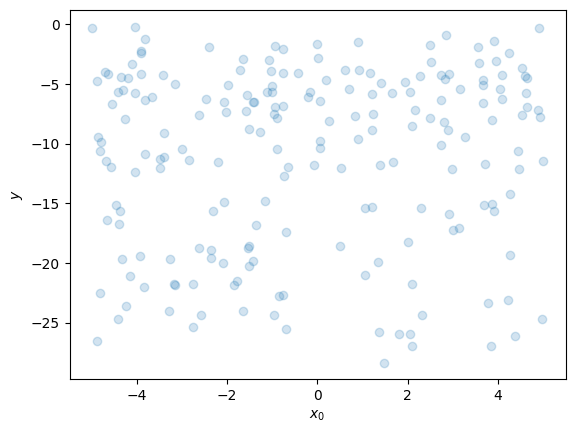

In [11]:
plt.scatter(X[:, 1], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

In [12]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


Model 2:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


Model 3:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


In [13]:
for model in models:
    print(model.latex())

\left(x_{5} x_{5} + \sin{\left(x_{0} + x_{1} \cdot 1.98 \right)} \left(-2.22\right) + 2.94\right) \left(-1.00\right)
- x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.22\right) - 2.93
- x_{5} x_{5} - \sin{\left(- x_{0} + x_{1} \left(-1.98\right) \right)} - 2.94


## Zadanie na 4.0

In [14]:
np.random.seed(0)

X = np.random.uniform(low=-15, high=15, size=(200, 6))

y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 2
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [15]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(

Model 2:


[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!


Model 3:


[ Info: Final population:
[ Info: Results saved to:


In [16]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-0.999\right) - 2.82
- x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 2.73
- x_{5} x_{5} - 2.71


In [17]:
np.random.seed(0)

X = np.random.uniform(low=-15, high=15, size=(200, 6))

y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 5
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [18]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


Model 1:


[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:


Model 2:


[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:


Model 3:


[ Info: Results saved to:


In [19]:
for model in models:
    print(model.latex())

x_{5} \left(-1.02\right) x_{5}
- x_{5} x_{5} - 2.32
- x_{5} x_{5} - 2.32


## Wyniki dla poszczegołnych zestawów operatorów i funkcji

Orginalna funkcja: $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$

### Bez szumu (-5, 5)
$$ x_{5} x_{5} \left(-0.986\right) + \cos{\left(\cos{\left(x_{1} + \cos{\left(x_{0} \right)} \right)} \right)} 5.28 - 7.31 $$
$$ - x_{5} x_{5} + \sin{\left(- x_{0} - x_{1} - x_{1} - 2.62 \cdot 10^{-7} \right)} \left(-2.20\right) - 3.00 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 3.01 $$

### Z szumem (-5, 5)

$$ \left(x_{5} x_{5} + \sin{\left(x_{0} + x_{1} \cdot 1.98 \right)} \left(-2.22\right) + 2.94\right) \left(-1.00\right) $$
$$ - x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.22\right) - 2.93 $$
$$ - x_{5} x_{5} - \sin{\left(- x_{0} + x_{1} \left(-1.98\right) \right)} - 2.94 $$

### Z szumem (-15, 15), wychylenie = 2

$$ x_{5} x_{5} \left(-0.999\right) - 2.82 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 2.73 $$
$$ - x_{5} x_{5} - 2.71 $$

### Z szumem (-15, 15), wychylenie = 5

$$ x_{5} \left(-1.02\right) x_{5} $$
$$ - x_{5} x_{5} - 2.32 $$
$$ - x_{5} x_{5} - 2.32 $$

## Zadanie na 5.0

In [3]:
from pysr import jl

jl.seval(
    """
import Pkg
Pkg.add("Primes")
"""
)

   Resolving package versions...
  No Changes to `~/Desktop/Metody-i-algorytmy-optymalizacji/.env/julia_env/Project.toml`
  No Changes to `~/Desktop/Metody-i-algorytmy-optymalizacji/.env/julia_env/Manifest.toml`


In [4]:
jl.seval("using Primes: prime")

In [5]:
jl.seval(
    """
function p(i::T) where T
    if 0.5 < i < 1000
        return T(prime(round(Int, i)))
    else
        return T(NaN)
    end
end
"""
)

p (generic function with 1 method)

In [6]:
primes = {i: jl.p(i * 1.0) for i in range(1, 999)}

In [7]:
np.random.seed(0)
X = np.random.uniform(low=0, high=5, size=(200, 6))
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

In [8]:
## Dodajemy operator p
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin", "p"], ["cos", "exp", "sin", "log", "p"], ["cos", "sin", "p"]]
sizes = [20, 30, 15]

models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Model 1:


[ Info: Started!



Expressions evaluated per second: 5.010e+05
Progress: 2773 / 3100 total iterations (89.452%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.155e+01  0.000e+00  y = -11.823
3           6.703e+00  1.109e+00  y = x₅ * -4.7489
5           6.103e+00  4.689e-02  y = (x₅ + -0.30562) * -5.2241
6           2.538e+00  8.774e-01  y = exp(x₅ * 0.46168) * -2.9327
7           2.433e+00  4.241e-02  y = (x₅ * (x₅ * -0.99887)) + -3.2024
9           2.424e+00  1.860e-03  y = (((x₅ * -1.0494) + 0.28078) * x₅) + -3.4878
11          2.320e+00  2.175e-02  y = ((x₅ * x₅) * -0.99619) + (cos(sin(x₁)) + -3.975)
12          2.316e+00  1.808e-03  y = cos(x₁ * 2.164) + ((x₅ * (x₅ * -0.989)) + -3.1919)
13          2.253e+00  2.758e-02  y = (((x₅ * x₅) * -0.99207) + -3.5813) + cos(sin(x₁) * -1....
          

[ Info: Final population:
[ Info: Results saved to:


...

Model 3:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


  - outputs/20260516_180748_fGJt7w/hall_of_fame.csv

Expressions evaluated per second: 4.840e+05
Progress: 2892 / 3100 total iterations (93.290%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.155e+01  0.000e+00  y = -11.823
3           6.703e+00  1.109e+00  y = x₅ * -4.7488
5           2.433e+00  5.068e-01  y = -3.193 - (x₅ * x₅)
7           2.432e+00  1.980e-04  y = ((0.021779 - x₅) * x₅) - 3.2486
9           2.321e+00  2.325e-02  y = cos(sin(x₁)) - ((x₅ * x₅) + 3.9421)
11          2.267e+00  1.183e-02  y = (cos(cos(x₁)) * -2.391) + (-1.3229 - (x₅ * x₅))
12          7.238e-01  1.142e+00  y = (sin((x₁ + x₀) + x₁) + -3.1051) - (x₅ * x₅)
14          8.571e-13  1.373e+01  y = ((sin(x₀ + (x₁ + x₁)) + -1.3636) * 2.2) - (x₅ * x₅)
──────────────────────────────────────────────────────

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.155e+01  0.000e+00  y = -11.823
3           6.703e+00  1.109e+00  y = x₅ * -4.7488
5           2.433e+00  5.068e-01  y = -3.193 - (x₅ * x₅)
7           2.432e+00  1.980e-04  y = ((0.021779 - x₅) * x₅) - 3.2486
9           2.321e+00  2.325e-02  y = cos(sin(x₁)) - ((x₅ * x₅) + 3.9421)
11          2.267e+00  1.183e-02  y = (cos(cos(x₁)) * -2.391) + (-1.3229 - (x₅ * x₅))
12          7.238e-01  1.142e+00  y = (sin((x₁ + x₀) + x₁) + -3.1051) - (x₅ * x₅)
14          8.571e-13  1.373e+01  y = ((sin(x₀ + (x₁ + x₁)) + -1.3636) * 2.2) - (x₅ * x₅)
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260516_180759_4ziWpJ/hall_of_fame.csv


In [9]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-1.00\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} 2.20 - 3.00
- x_{5} x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} - 1.57 \right)} 2.20 - 3.00
- x_{5} x_{5} + \left(\sin{\left(x_{0} + x_{1} + x_{1} \right)} - 1.36\right) 2.20


In [14]:
X = np.random.uniform(low=0, high=5, size=(200, 6))
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

noise_level = 0.5
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [15]:
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.047e+01  0.000e+00  y = -10.695
3           7.406e+00  1.050e+00  y = x₅ * -4.3867
5           4.263e+00  2.761e-01  y = (x₅ * x₅) * -1.1327
6           2.997e+00  3.525e-01  y = exp(x₅ * 0.50694) * -2.2809
7           2.631e+00  1.301e-01  y = ((x₅ * -1.0053) * x₅) + -1.9473
9           2.627e+00  7.729e-04  y = (((x₅ * -0.97251) + -0.17737) * x₅) + -1.7762
11          2.534e+00  1.812e-02  y = (((x₅ * -1.0079) * x₅) + -2.7132) + cos(cos(x₂))
13          2.488e+00  9.156e-03  y = ((cos(cos(x₂)) + -1.6105) * 2.3051) + ((x₅ * x₅) * -1....
                                      0113)
14          9.751e-01  9.366e-01  y = ((x₅ * (x₅ * -1.0014)) + -1.9597) + sin((x₁ * 2.0158) ...
                                      + x₀)
16          2.960e-01  5.961e-01  y = (((x₅ * x₅) * -0.4586) + (sin(x₀ + (x₁ * 2.0015)) + -0...
                   

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.047e+01  0.000e+00  y = -10.695
3           7.406e+00  1.050e+00  y = x₅ * -4.3867
5           2.633e+00  5.171e-01  y = -1.9934 - (x₅ * x₅)
7           2.630e+00  5.663e-04  y = -1.8959 - (x₅ * (x₅ + 0.037874))
9           2.537e+00  1.794e-02  y = cos(cos(x₂)) + (-2.7817 - (x₅ * x₅))
10          2.509e+00  1.106e-02  y = (sin(x₂ ^ -5.1798) + -2.105) - (x₅ * x₅)
11          2.485e+00  9.580e-03  y = -2.1096 - ((x₅ * x₅) - sin(x₀ - sin(x₁)))
12          9.752e-01  9.356e-01  y = -1.9721 - ((x₅ * x₅) - sin((x₁ * 2.0159) + x₀))
14          2.966e-01  5.952e-01  y = (-1.9517 - (x₅ * x₅)) - (sin((x₁ + x₁) + x₀) * -2.1733...
                                      )
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260516_181058_OXldGX/hall_of_fame.csv


In [16]:
for model in models:
    print(model.latex())

\left(x_{5} x_{5} \left(-0.459\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} - 0.910\right) 2.17
- (x_{5} x_{5} + \sin{\left(- x_{0} + x_{1} \left(-2.00\right) \right)} 2.17) - 1.95
- x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.17\right) - 1.95


In [18]:
X = np.random.uniform(low=0, high=15, size=(200, 6))
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

noise_level = 2
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [19]:
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.820e+03  0.000e+00  y = -103.12
3           2.470e+02  1.369e+00  y = x₅ * -15.111
5           2.450e+02  4.075e-03  y = (x₅ * -14.809) + -2.7722
6           1.460e+02  5.173e-01  y = p(x₅ + 2.4792) * -3.9444
7           6.957e+00  3.044e+00  y = ((x₅ * -0.99765) * x₅) + -41.046
9           6.949e+00  6.260e-04  y = (((x₅ + 0.092645) * -0.99186) * x₅) + -40.785
10          6.842e+00  1.551e-02  y = sin(x₀) + ((x₅ * (x₅ * -0.99713)) + -41.228)
11          6.779e+00  9.145e-03  y = (-41.208 + sin(sin(x₀))) + ((x₅ * -0.99718) * x₅)
12          6.518e+00  3.935e-02  y = (((x₅ * x₅) * -0.99753) + -41.136) + cos(x₀ * 2.3187)
13          6.341e+00  2.751e-02  y = ((x₅ * (x₅ * -0.99695)) + -41.192) + sin(sin(x₁) + x₀)
14          5.090e+00  2.198e-01  y = ((x₅ * (x₅ * -0.99733)) + sin(x₁ + (x₀ + x₁))) + -41.0...
                           

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.820e+03  0.000e+00  y = -103.12
3           2.470e+02  1.369e+00  y = x₅ * -15.111
5           6.979e+00  1.783e+00  y = -40.9 - (x₅ * x₅)
7           6.957e+00  1.517e-03  y = -41.047 - (x₅ * (x₅ * 0.99765))
8           6.873e+00  1.216e-02  y = (sin(x₀) + -41.05) - (x₅ * x₅)
9           6.810e+00  9.256e-03  y = (sin(sin(x₀)) + -41.032) - (x₅ * x₅)
10          6.701e+00  1.610e-02  y = -40.893 - (sin(x₀ * 23.74) + (x₅ * x₅))
11          6.377e+00  4.967e-02  y = (sin(x₀ + sin(x₁)) + -41.002) - (x₅ * x₅)
12          5.117e+00  2.200e-01  y = sin(x₁ + (x₀ + x₁)) + (-40.856 - (x₅ * x₅))
13          5.094e+00  4.639e-03  y = (exp(sin(x₁ + (x₀ + x₁))) + -42.117) - (x₅ * x₅)
14          5.090e+00  7.029e-04  y = sin(x₁ + (x₀ + x₁)) + (-41.022 - (x₅ * (x₅ * 0.99733))...
                                      )
15          4.538e+00  1.14

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.820e+03  0.000e+00  y = -103.12
3           2.470e+02  1.369e+00  y = x₅ * -15.111
5           6.956e+00  1.785e+00  y = -41.029 - (x₅ ^ 1.9991)
7           6.955e+00  6.661e-05  y = -40.828 - ((x₅ + 0.040418) ^ 1.9969)
8           6.839e+00  1.684e-02  y = sin(x₀) - ((x₅ ^ 1.9989) + 41.22)
9           6.777e+00  9.112e-03  y = sin(sin(x₀)) - ((x₅ ^ 1.9988) + 41.204)
10          6.743e+00  5.073e-03  y = cos(1.2504 ^ x₀) - ((x₅ ^ 1.9989) + 41.087)
11          6.339e+00  6.170e-02  y = sin(x₀ + sin(x₁)) - ((x₅ ^ 1.9987) + 41.195)
12          5.089e+00  2.197e-01  y = sin((x₁ + x₀) + x₁) - ((x₅ ^ 1.999) + 41.001)
14          5.083e+00  5.761e-04  y = sin(((x₁ + x₀) + x₁) - -0.064204) - ((x₅ ^ 1.999) + 41...
                                      .001)
15          5.031e+00  1.032e-02  y = (sin((x₁ + x₀) + x₁) - ((x₅ ^ 1.9987) + 41.195

In [20]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-0.997\right) + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 41.0
- x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 40.9
- x_{5}^{2.00} - 41.0


In [21]:
X = np.random.uniform(low=-15, high=15, size=(200, 6))
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

noise_level = 5
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [22]:
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.630e+05
Progress: 3065 / 3100 total iterations (98.871%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.493e+03  0.000e+00  y = -81.911
3           4.491e+03  1.353e-05  y = x₁ + -81.555
4           4.490e+03  -0.000e+00  y = cos(x₁) + -81.874
5           2.847e+01  5.060e+00  y = (x₅ * -1.0214) * x₅
7           2.411e+01  8.306e-02  y = (x₅ * (x₅ * -0.99764)) + -3.2244
9           2.351e+01  1.269e-02  y = (x₅ * ((x₅ + -0.088485) * -0.999)) + -3.1768
12          2.293e+01  8.267e-03  y = (((x₅ * (x₅ + -0.093654)) + cos(x₅)) * -0.99741) + -3....
                                      2966
14          2.202e+01  2.041e-02  y = sin((x₁ * 2.0256) + x₀) + (((x₅ * x₅) * -0.99786) + -3...
                                      .165)
16          2.096

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.290e+05
Progress: 1672 / 3100 total iterations (53.935%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.493e+03  0.000e+00  y = -81.915
3           4.428e+03  7.043e-03  y = -80.85 - x₂
5           2.414e+01  2.606e+00  y = -3.0387 - (x₅ * x₅)
7           2.351e+01  1.311e-02  y = -3.0983 - ((x₅ + -0.089251) * x₅)
9           2.351e+01  9.350e-05  y = ((x₅ * (0.088484 - x₅)) * 0.999) - 3.1768
10          2.296e+01  2.351e-02  y = (-3.094 - ((x₅ + -0.095725) * x₅)) - cos(x₅)
11          2.216e+01  3.544e-02  y = cos(exp(0.96175 - x₅)) + (-3.5075 - (x₅ * x₅))
14          2.186e+01  4.594e-03  y = ((cos(exp(0.96175 - x₅)) + -3.1557) - (x₅ * x₅)) - cos...
                                      (x₅)
16          2.096e+01  2.109e-02  y = (-2.8959 - 

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.493e+03  0.000e+00  y = -81.913
3           4.428e+03  7.043e-03  y = -80.851 - x₂
5           2.414e+01  2.606e+00  y = -3.0387 - (x₅ * x₅)
7           2.351e+01  1.311e-02  y = ((0.089113 - x₅) * x₅) - 3.0991
9           2.351e+01  9.350e-05  y = (((0.088477 - x₅) * x₅) - 3.1801) * 0.999
10          2.209e+01  6.227e-02  y = cos(0.59456 ^ x₅) + (-3.5101 - (x₅ * x₅))
12          2.123e+01  1.994e-02  y = (-3.6431 - (x₅ * x₅)) + (cos(0.59457 ^ x₅) * 2.2601)
13          2.121e+01  6.217e-04  y = ((cos(0.59457 ^ x₅) * p(1.212)) + -3.6431) - (x₅ * x₅)
14          2.101e+01  9.797e-03  y = (cos(0.59457 ^ x₅) * 2.2601) + ((-3.6431 - (x₅ * x₅)) ...
                                      + -0.56918)
15          2.090e+01  4.865e-03  y = (cos(0.59457 ^ x₅) * (2.2601 + cos(x₂))) + (-3.6431 - ...
                                      (x₅ * x₅

In [23]:
for model in models:
    print(model.latex())

x_{5} \left(-1.02\right) x_{5}
- x_{5} x_{5} - 3.04
- x_{5} x_{5} - 3.04


## Wyniki dla poszczegołnych zestawów operatorów i funkcji

Orginalna funkcja: $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$

### Bez szumu (0, 5)
$$ x_{5} x_{5} \left(-1.00\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} 2.20 - 3.00 $$
$$ - x_{5} x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} - 1.57 \right)} 2.20 - 3.00 $$
$$ - x_{5} x_{5} + \left(\sin{\left(x_{0} + x_{1} + x_{1} \right)} - 1.36\right) 2.20 $$

### Z szumem (0, 5), wychylenie = 0.5 

$$ \left(x_{5} x_{5} \left(-0.459\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} - 0.910\right) 2.17 $$
$$ - (x_{5} x_{5} + \sin{\left(- x_{0} + x_{1} \left(-2.00\right) \right)} 2.17) - 1.95 $$
$$ - x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.17\right) - 1.95 $$

### Z szumem (0, 15), wychylenie = 2

$$ x_{5} x_{5} \left(-0.997\right) + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 41.0 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 40.9 $$
$$ - x_{5}^{2.00} - 41.0 $$

### Z szumem (0, 15), wychylenie = 5

$$ x_{5} \left(-1.02\right) x_{5} $$
$$ - x_{5} x_{5} - 3.04 $$
$$ - x_{5} x_{5} - 3.04 $$